# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [194]:
#The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [195]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Timing model performance
import time

In [196]:
df_bank = pd.read_csv('bank-additional-full.csv', sep = ';')

In [197]:
df_bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [198]:
# Dataset shape
print("Shape of the dataset:",df_bank.shape)

# Data types and missing values
df_bank.info()

# Statistical summary
df_bank.describe()

Shape of the dataset: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 1

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [199]:
#Data types are already appropriate:numeric columns int64 / float64 , categorical columns object

In [200]:
# Check missing values
df_bank.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [201]:
# Value counts for categorical variables to analyse the type of content
categorical_columns = df_bank.select_dtypes(include='object').columns

for column in categorical_columns:
    print(df_bank[column].value_counts())

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
contact
cellular     26144
telephone    15044
Name: count, dtype: in

In [202]:
#There are no missing values in the dataset.However, several categorical variables contain the value 'unknown',which may represent missing or unavailable information.
#These values were retained because they may contain meaningful information and can be handled naturally through one-hot encoding. (next session)

In [203]:
#Check for duplicate values
df_bank.duplicated().sum()

np.int64(12)

In [204]:
# Remove duplicate rows
df_bank = df_bank.drop_duplicates()
# Verify duplicates were removed
print("Remaining duplicates:", df_bank.duplicated().sum())

Remaining duplicates: 0


In [205]:
# After the identificaiton of the Duplicate rows we removed them from the dataset:
#to prevent bias in the machine learning models and to have a more reliable model evaluation.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [206]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

In [207]:
#Business Objective:

#The business objective is to predict whether a client will subscribe to a term deposit based on demographic, financial, and campaign-related information.
#Accurate predictions help the bank optimize marketing campaigns, improve targeting efficiency, reduce costs, and maximize return on investment

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [208]:
# Target distribution
df_bank['y'].value_counts()

,count
y,
no,36537
yes,4639


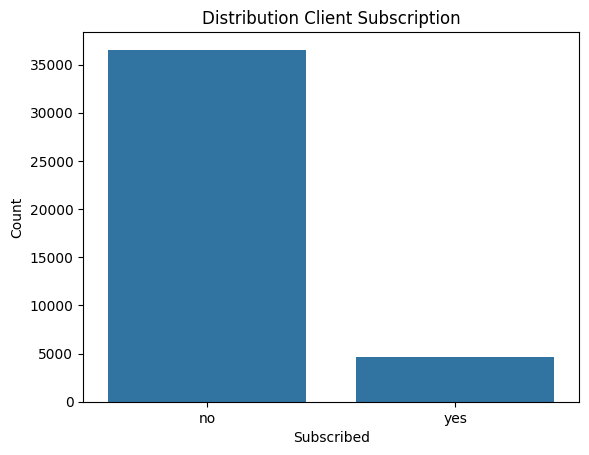

In [209]:
# Plot target distribution

sns.countplot(data=df_bank, x='y')

plt.title('Distribution Client Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

In [210]:
#The dataset is imbalanced

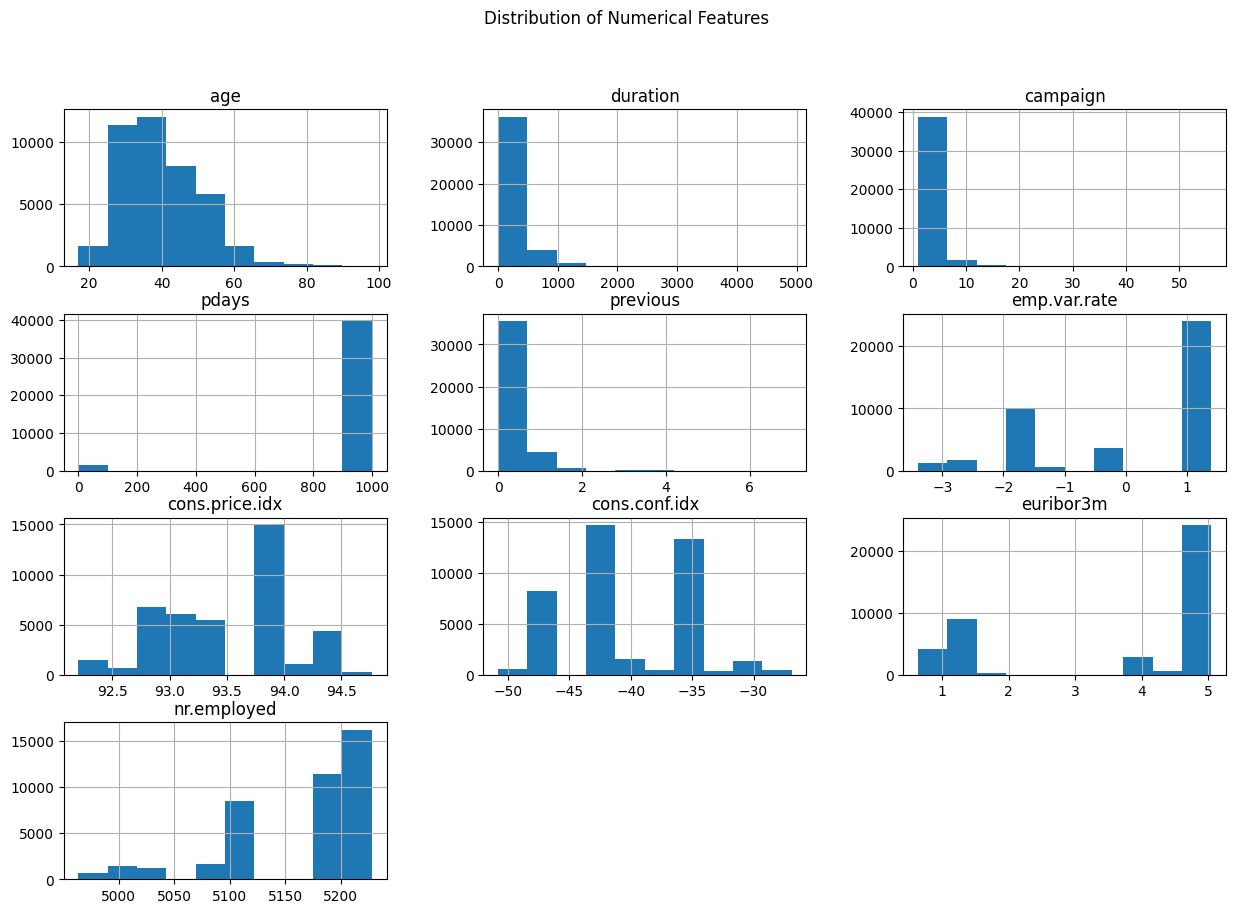

In [211]:
numeric_cols = ['age','duration','campaign', 'pdays', 'previous', 'emp.var.rate','cons.price.idx', 'cons.conf.idx','euribor3m','nr.employed']
df_bank[numeric_cols].hist(figsize=(15,10),bins=10)

plt.suptitle('Distribution of Numerical Features')
plt.show()

In [212]:
#Majority of the targeted clients are between 30 and 50 years old, seniors are heavily underrepresented in this campaign.
#pdays and previous show that the most of the client is a first-time marketing contact

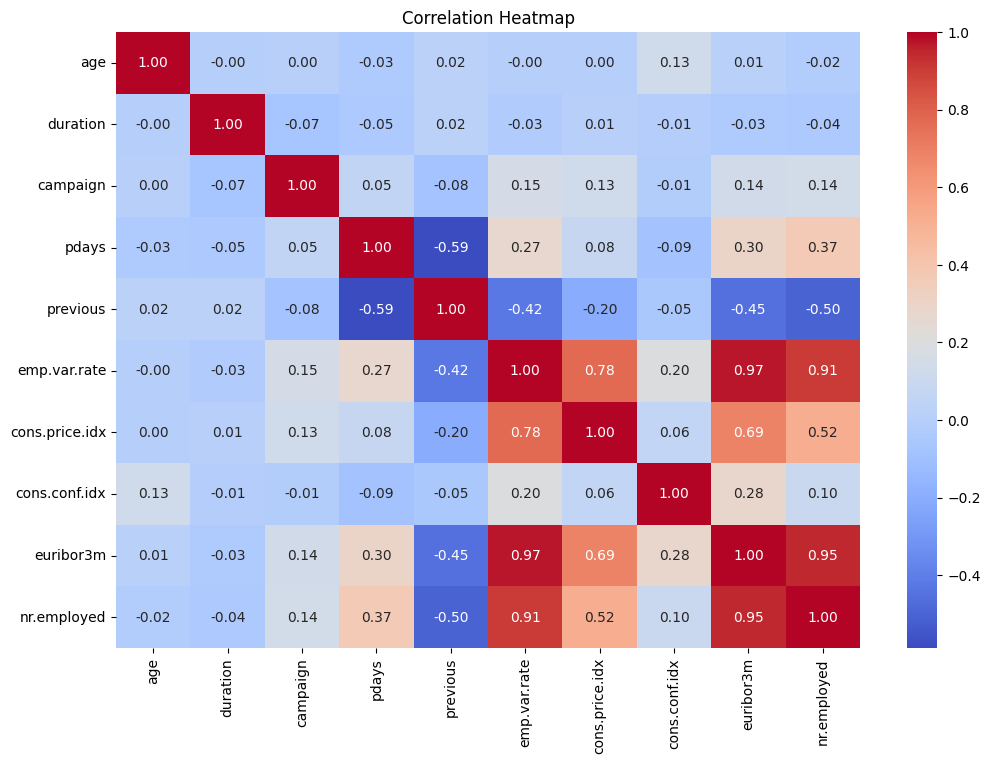

In [213]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_bank[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [214]:
# I can see some multicollinearity effect in the red zone. In the Economic Indicators
#Age and duration are independent demographic factors

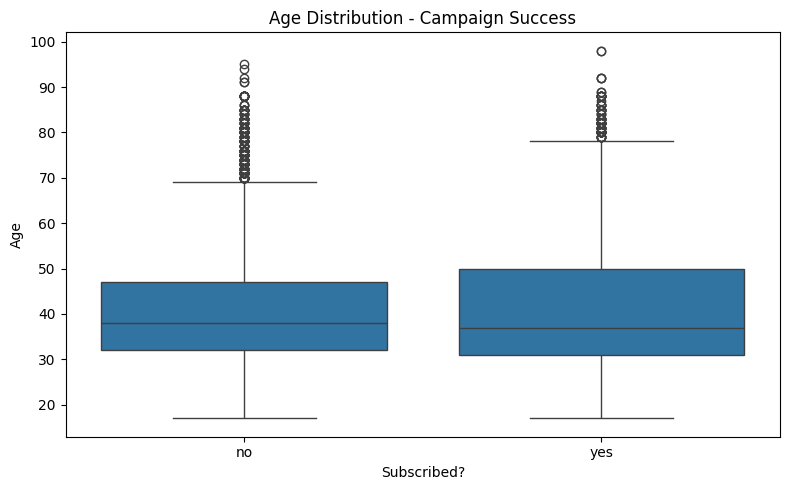

In [215]:
#FEATURES vs TARGET
# Box plot to see how age relates to campaign success
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='age', data=df_bank)
plt.title('Age Distribution - Campaign Success')
plt.xlabel('Subscribed?')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

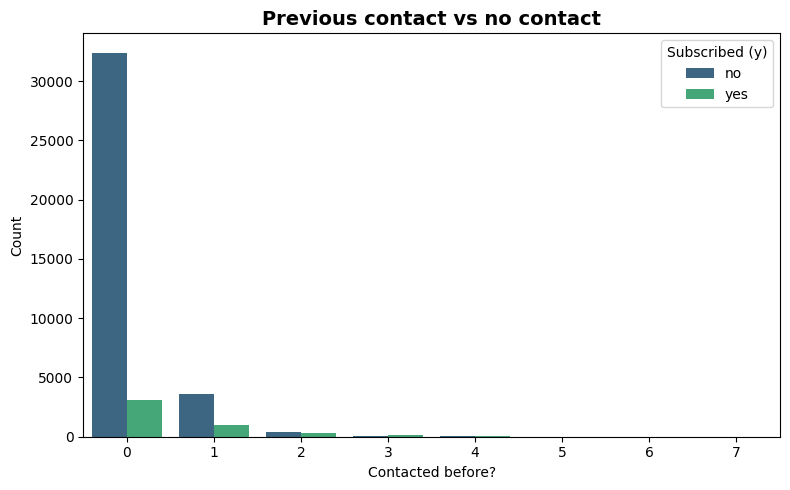

In [216]:
# Plotting the previous contact success rate
plt.figure(figsize=(8, 5))
sns.countplot(x='previous', hue='y', data=df_bank, palette='viridis')
plt.title('Previous contact vs no contact', fontsize=14, fontweight='bold')
plt.xlabel('Contacted before?')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

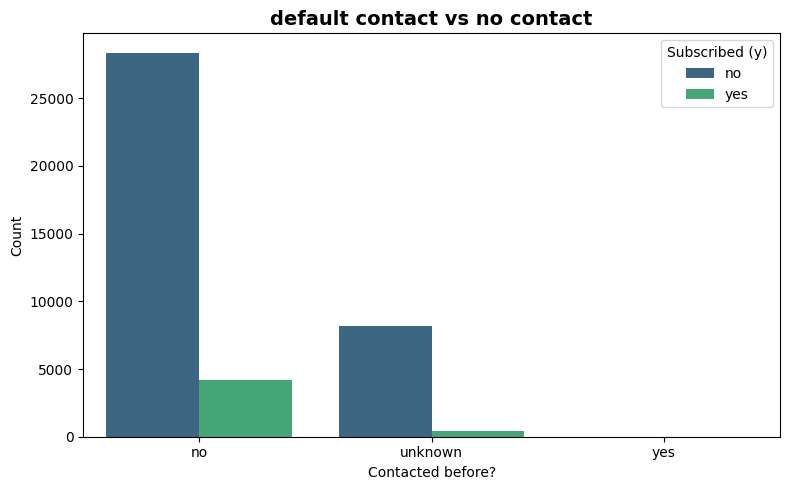

In [217]:
# Plotting the default contact success rate
plt.figure(figsize=(8, 5))
sns.countplot(x='default', hue='y', data=df_bank, palette='viridis')
plt.title('default contact vs no contact', fontsize=14, fontweight='bold')
plt.xlabel('Contacted before?')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

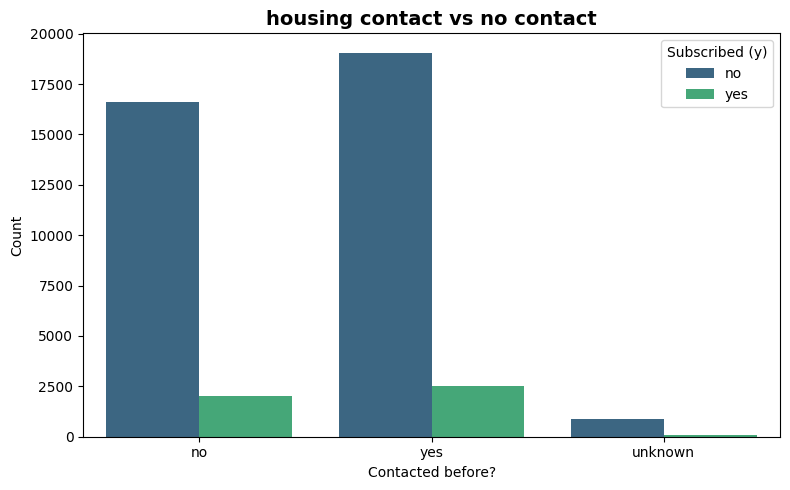

In [218]:
# Plotting the housing contact success rate
plt.figure(figsize=(8, 5))
sns.countplot(x='housing', hue='y', data=df_bank, palette='viridis')
plt.title('housing contact vs no contact', fontsize=14, fontweight='bold')
plt.xlabel('Contacted before?')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

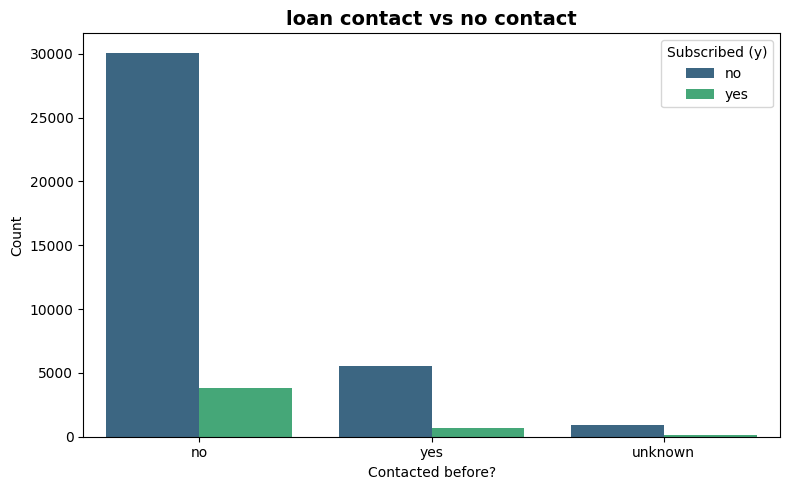

In [219]:
# Plotting the loan contact success rate
plt.figure(figsize=(8, 5))
sns.countplot(x='loan', hue='y', data=df_bank, palette='viridis')
plt.title('loan contact vs no contact', fontsize=14, fontweight='bold')
plt.xlabel('Contacted before?')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

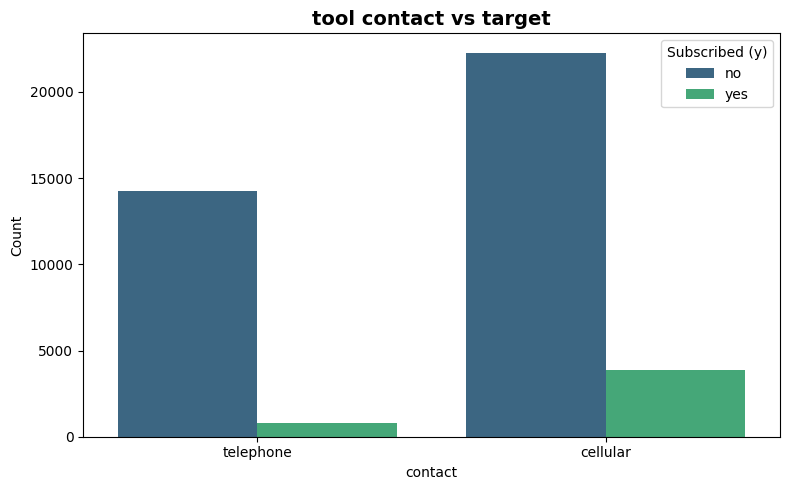

In [220]:
# Plotting the tool contact success rate
plt.figure(figsize=(8, 5))
sns.countplot(x='contact', hue='y', data=df_bank, palette='viridis')
plt.title('tool contact vs target', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

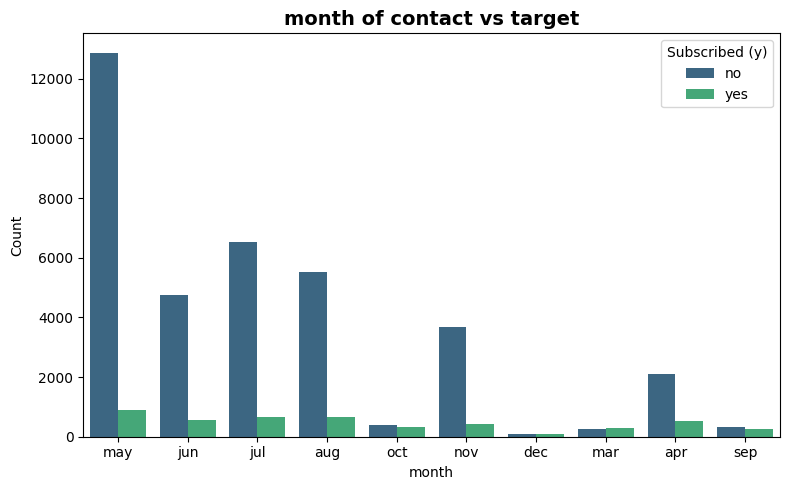

In [221]:
# Plotting the month of contact success rate
plt.figure(figsize=(8, 5))
sns.countplot(x='month', hue='y', data=df_bank, palette='viridis')
plt.title('month of contact vs target', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

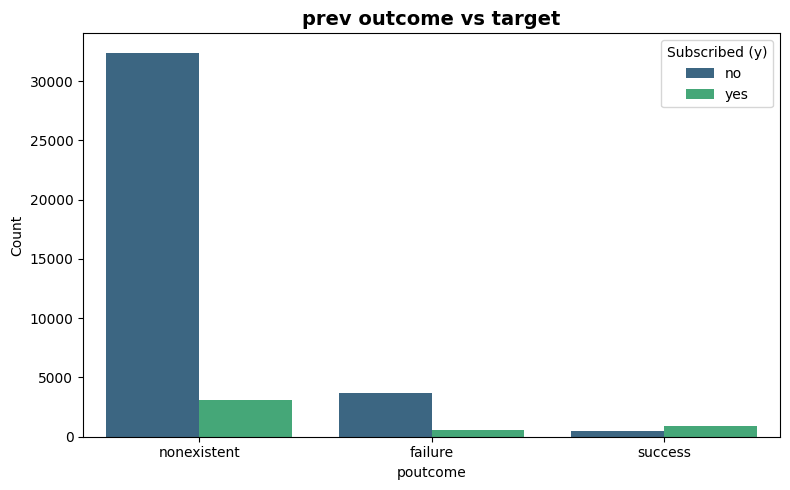

In [222]:
# Plotting the prev outcome of contact success rate
plt.figure(figsize=(8, 5))
sns.countplot(x='poutcome', hue='y', data=df_bank, palette='viridis')
plt.title('prev outcome vs target', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

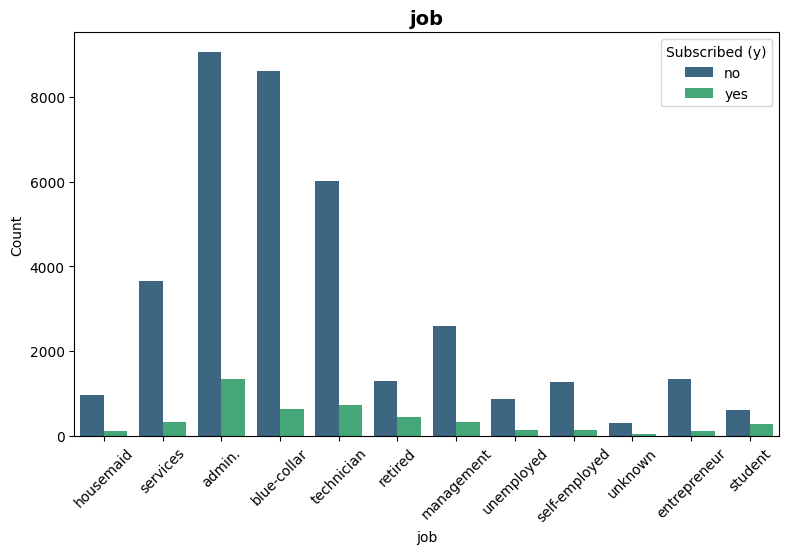

In [223]:
# Plotting the success rate for type of job

plt.figure(figsize=(8, 5))
sns.countplot(x='job', hue='y', data=df_bank, palette='viridis')
plt.title('job', fontsize=14, fontweight='bold')
plt.xlabel('job')
plt.ylabel('Count')
plt.legend(title='Subscribed (y)')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

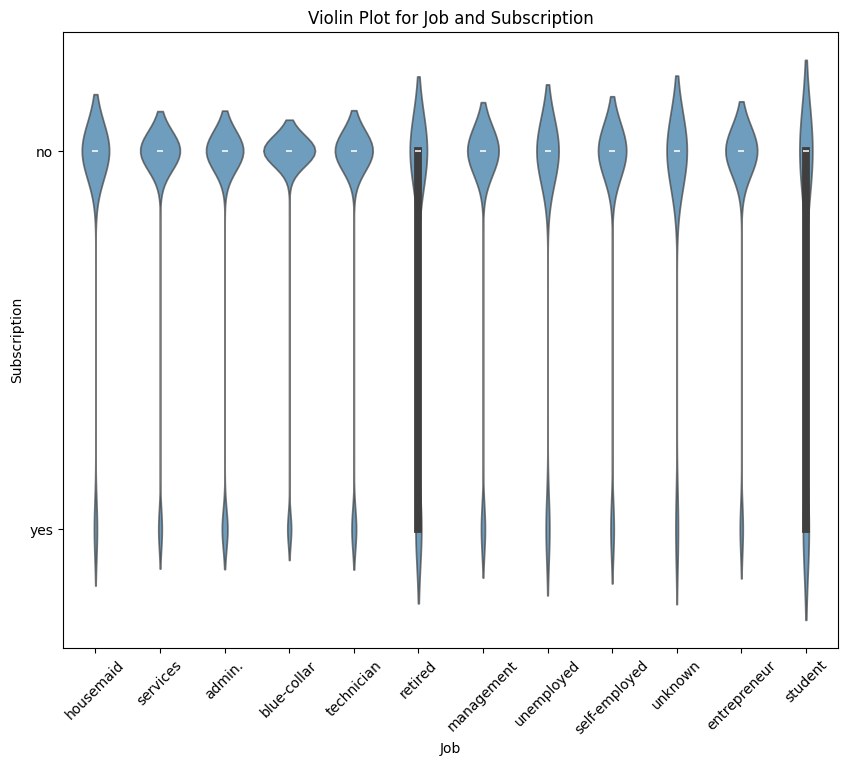

In [224]:
 # Plotting the success rate for type of job (different rappresentation then before)
plt.figure(figsize=(10, 8))

sns.violinplot(x="job", y="y", data=df_bank, alpha=0.7)

plt.title('Violin Plot for Job and Subscription')
plt.xlabel('Job')
plt.ylabel('Subscription')
plt.xticks(rotation=45)
plt.show()

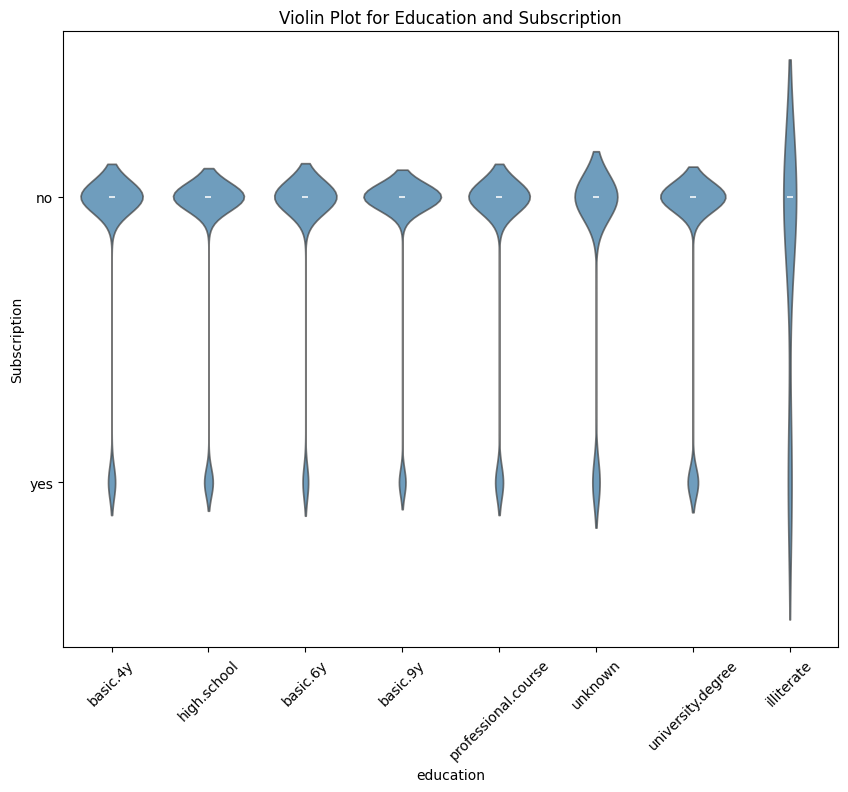

In [225]:
 # Plotting the success rate for type of education
plt.figure(figsize=(10, 8))

sns.violinplot(x="education", y="y", data=df_bank, alpha=0.7)

plt.title('Violin Plot for Education and Subscription')
plt.xlabel('education')
plt.ylabel('Subscription')
plt.xticks(rotation=45)
plt.show()

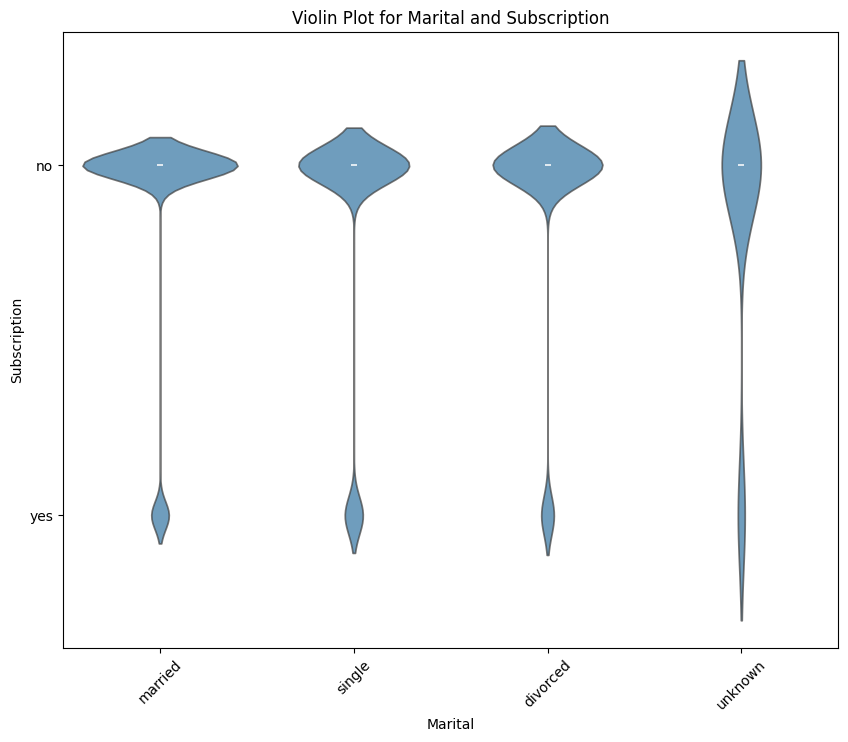

In [226]:
 # Plotting the success rate for type of marital status
plt.figure(figsize=(10, 8))

sns.violinplot(x="marital", y="y", data=df_bank, alpha=0.7)

plt.title('Violin Plot for Marital and Subscription')
plt.xlabel('Marital')
plt.ylabel('Subscription')
plt.xticks(rotation=45)
plt.show()

In [227]:
#feature engeneering

In [228]:
df_bank = df_bank.drop('duration', axis=1)


In [229]:
df_bank['y'].value_counts()

,count
y,
no,36537
yes,4639


In [230]:
# Convert target variable to binary
df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})
# Create a binary column is_new_customer
df_bank['is_new_customer'] = df_bank['pdays'].apply(lambda x: 'Yes' if x == 999 else 'No')
df_bank['y']

,y
0,0
1,0
2,0
3,0
4,0
...,...
41183,1
41184,0
41185,0
41186,1


In [231]:
#Based on the analysis target vs variable I decided to mantain the following explanation variables.
# Select categorical columns
categorical_cols = ["job",
                    "marital",
                    "education",
                    "loan",
                    "month",
                    "poutcome",
                    "is_new_customer"]

num_cols=["previous","euribor3m"]
#D# Drop Redundant Features and slice the data before encoding
# This ensures you don't accidentally keep unneeded columns like emp.var.rate
df_filtered = df_bank[categorical_cols + num_cols + ['y']]

# Apply one-hot encoding
bank_final = pd.get_dummies(
    df_filtered,
    columns=categorical_cols,
    drop_first=True
)
df_filtered


,job,marital,education,loan,month,poutcome,is_new_customer,previous,euribor3m,y
0,housemaid,married,basic.4y,no,may,nonexistent,Yes,0,4.857,0
1,services,married,high.school,no,may,nonexistent,Yes,0,4.857,0
2,services,married,high.school,no,may,nonexistent,Yes,0,4.857,0
3,admin.,married,basic.6y,no,may,nonexistent,Yes,0,4.857,0
4,services,married,high.school,yes,may,nonexistent,Yes,0,4.857,0
...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,nov,nonexistent,Yes,0,1.028,1
41184,blue-collar,married,professional.course,no,nov,nonexistent,Yes,0,1.028,0
41185,retired,married,university.degree,no,nov,nonexistent,Yes,0,1.028,0
41186,technician,married,professional.course,no,nov,nonexistent,Yes,0,1.028,1


In [232]:

# Features: Everything EXCEPT the target column 'y'
X = bank_final.drop(columns=['y'])

# Target
y = bank_final['y']

In [233]:
# Correlation with target
correlation_target = bank_final.corr()['y'].sort_values(ascending=False)

print(correlation_target.head(15))

y                              1.000000
poutcome_success               0.316302
previous                       0.230202
month_mar                      0.144027
month_oct                      0.137538
month_sep                      0.126079
job_student                    0.093962
job_retired                    0.092364
month_dec                      0.079311
marital_single                 0.054209
education_university.degree    0.050267
education_unknown              0.021476
job_unemployed                 0.014749
education_illiterate           0.007246
marital_unknown                0.005210
Name: y, dtype: float64


In [234]:

#poutcome_success - is the strongest predictor. Clients who previously responded successfully to a marketing campaign are much more likely to subscribe again.
#Past campaign success is highly valuable. The bank should prioritize customers with positive previous interactions
#previouvs - is also a strong predictor. Clients contacted more times in previous campaigns are more likely to subscribe.
#month_mar, month_oct, month_sep - Certain months show higher subscription rates. Maybe some seasonality effect.



### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [235]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [236]:
# Initialize scaler
scaler = StandardScaler()

# Scale data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [237]:
# Baseline accuracy
baseline_accuracy = y.value_counts(normalize=True).max()

print("Baseline Accuracy:", round(baseline_accuracy, 4))

Baseline Accuracy: 0.8873


In [238]:
#The baseline model predicts the majority class only.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [239]:
# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(log_accuracy, 4))

Logistic Regression Accuracy: 0.8974


In [240]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.91      0.99      0.94      7308
           1       0.66      0.19      0.29       928

    accuracy                           0.90      8236
   macro avg       0.78      0.59      0.62      8236
weighted avg       0.88      0.90      0.87      8236



In [241]:
#The Logistic Regression model got an accuracy of 0.8974, which looks very good at first.
#Precision (0.66): When the model actually risks making a "Yes" prediction, it is right 66% of the time. That’s decent.
#Recall (0.19): This is the critical failure point. A recall of 0.19 means the model only successfully identified 19% of the actual buyers. It completely missed the other 81% of potential revenue.

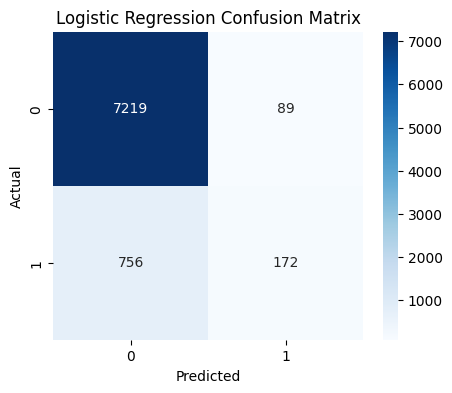

In [242]:
# Confusion matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [243]:
#Overall, the confusion matrix confirms that the dataset is imbalanced and the model is biased toward predicting class 0 more often.
#While the overall accuracy is high, the model performance for positive cases still needs improvement.

In [244]:
# The accuracy of the Logistic Regression model is 0.8983, which means the model correctly predicted about 89.83% of the test samples

### Problem 9: Score the Model

What is the accuracy of your model?

In [245]:
# Accuracy : 89.7%

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [246]:
# Differents models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Store results
results = []

# Train and evaluate each model
for name, model in models.items():

    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Predict classes for Accuracy, Recall, and F1-Score
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Predict probabilities for ROC-AUC score
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate Accuracies
    train_accuracy = model.score(X_train_scaled, y_train)
    test_accuracy = model.score(X_test_scaled, y_test)

    # Calculate handling metrics for Class 1 (the buyers)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)

    results.append({
        'Model': name,
        'Train Time': round(train_time, 4),
        'Train Accuracy': round(train_accuracy, 4),
        'Test Accuracy': round(test_accuracy, 4),
        'Test Recall': round(test_recall, 4),
        'Test F1-Score': round(test_f1, 4),
        'Test ROC-AUC': round(test_roc_auc, 4)
    })

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Train Time,Train Accuracy,Test Accuracy,Test Recall,Test F1-Score,Test ROC-AUC
0,Logistic Regression,0.0568,0.8996,0.8974,0.1853,0.2893,0.7928
1,KNN,0.0063,0.9090,0.8871,0.2511,0.3338,0.7106
2,Decision Tree,0.1291,0.9512,0.8782,0.2888,0.3483,0.6164
3,SVM,221.7339,0.9046,0.8952,0.1886,0.2885,0.6845


/tmp/ipykernel_28810/544934407.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


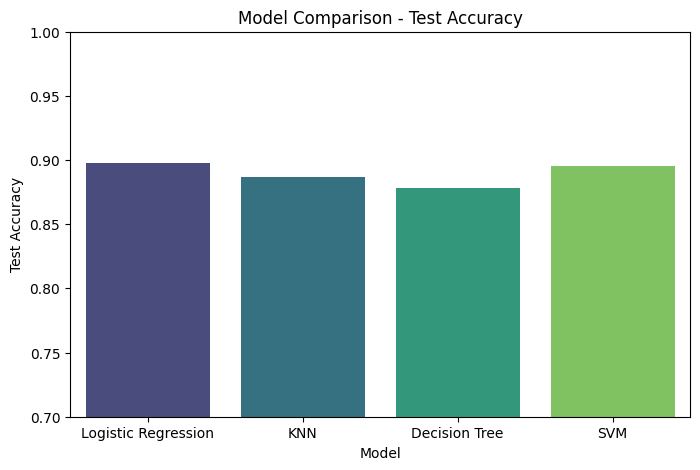

In [247]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='Test Accuracy',
    palette='viridis'
)

plt.title('Model Comparison - Test Accuracy')

plt.ylim(0.7, 1.0)

plt.show()

In [248]:
#Accuracy is misleading here. All models have ~88–90% accuracy, but Recall and F1 are very low. This strongly suggests an imbalanced dataset.
#Decision Tree detects positives best. Since it has the highest Recall and F1-score, it is likely the best model if detecting the minority/positive class matters.
#Logistic Regression has best ROC-AUC. ROC-AUC measures ranking/discrimination ability.
#SVM is inefficient Training time is massively larger while performance is not better.

In [249]:
# Cross-validation for Logistic Regression
cv_scores = cross_val_score(
    LogisticRegression(max_iter=500),
    X_train_scaled,
    y_train,
    cv=5
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.90057681 0.89996964 0.89936248 0.89784457 0.89799636]
Average CV Score: 0.899149969641773


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [250]:
# Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9]
}

# Grid Search
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Fit model
grid_knn.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:", grid_knn.best_params_)

# Best score
print("Best CV Score:", grid_knn.best_score_)

Best Parameters: {'n_neighbors': 9}
Best CV Score: 0.8940497874924104


In [251]:
# Best KNN model
best_knn = grid_knn.best_estimator_

# Predictions
y_pred_knn = best_knn.predict(X_test_scaled)

# Test accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_recall=recall_score(y_test, y_pred_knn)
knn_f1score=f1_score(y_test, y_pred_knn)
knn_roc_auc = roc_auc_score(y_test, y_pred_knn)


print("Test Accuracy:", round(knn_accuracy, 4))
print({  "Test Recall (Class 1)": round(knn_recall, 4),
        "Test F1-Score (Class 1)": round(knn_f1score, 4),
        "Test ROC-AUC": round(knn_roc_auc, 4)
    })

Test Accuracy: 0.8911
{'Test Recall (Class 1)': 0.2177, 'Test F1-Score (Class 1)': 0.3105, 'Test ROC-AUC': np.float64(0.5971)}


In [252]:
# Hyperparameter tuning for Decision Tree

# Define parameter grid
param_grid_tree = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

# Grid Search
grid_tree = GridSearchCV(
    estimator=tree_model,
    param_grid=param_grid_tree,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model
grid_tree.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:")
print(grid_tree.best_params_)

# Best cross-validation score
print("\nBest Cross-Validation Accuracy:")
print(round(grid_tree.best_score_,4))

Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.8992


In [253]:
# Best Decision Tree model
best_tree = grid_tree.best_estimator_

# Predictions
y_pred_tree = best_tree.predict(X_test_scaled)

# Test accuracy
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_recall=recall_score(y_test, y_pred_tree)
tree_f1score=f1_score(y_test, y_pred_tree)
tree_roc_auc = roc_auc_score(y_test, y_pred_tree)
print("Test Accuracy:", round(tree_accuracy,4))
print({  "Test Recall (Class 1)": round(tree_recall, 4),
        "Test F1-Score (Class 1)": round(tree_f1score, 4),
        "Test ROC-AUC": round(tree_roc_auc, 4)
    })



Test Accuracy: 0.8985
{'Test Recall (Class 1)': 0.1649, 'Test F1-Score (Class 1)': 0.268, 'Test ROC-AUC': np.float64(0.5783)}


In [254]:
# Get feature names
feature_names = X.columns

# Logistic Regression coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_model.coef_[0]
})

# Absolute importance
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()

# Sort by importance
coefficients = coefficients.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient,Abs_Coefficient
1,euribor3m,-0.871668,0.871668
30,month_may,-0.303084,0.303084
36,is_new_customer_Yes,-0.216004,0.216004
27,month_jul,0.214045,0.214045
34,poutcome_nonexistent,0.186748,0.186748
35,poutcome_success,0.154131,0.154131
29,month_mar,0.121949,0.121949
28,month_jun,0.113261,0.113261
25,month_aug,0.095552,0.095552
2,job_blue-collar,-0.094148,0.094148


/tmp/ipykernel_28810/583988401.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


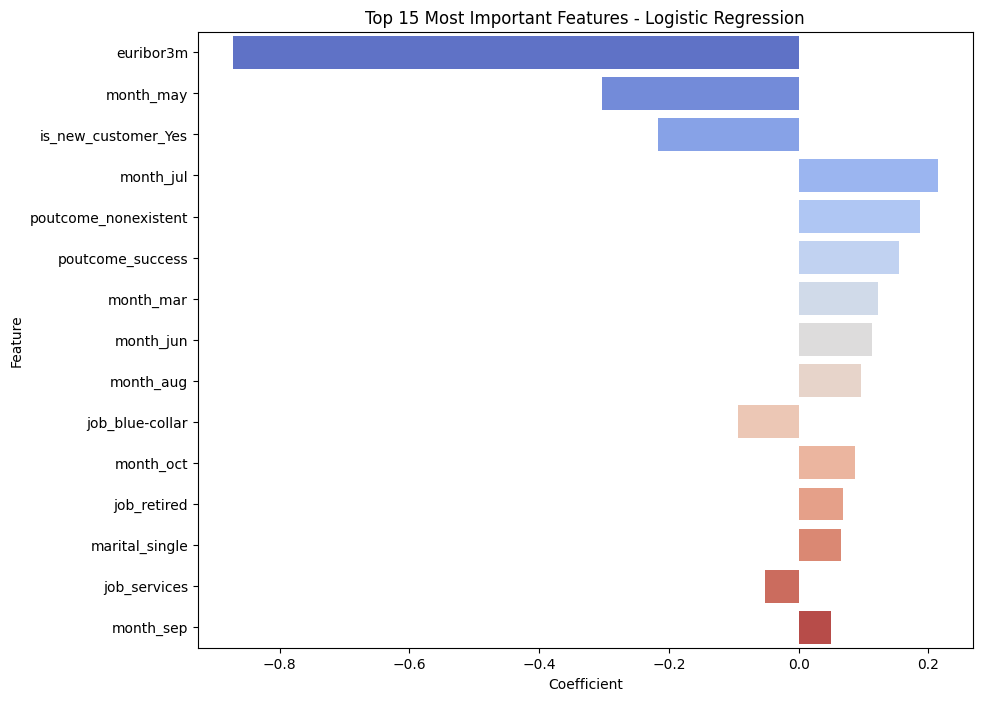

In [255]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=coefficients.head(15),
    x='Coefficient',
    y='Feature',
    palette='coolwarm'
)

plt.title('Top 15 Most Important Features - Logistic Regression')

plt.show()

In [256]:
# Feature importance from Decision Tree
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,euribor3m,0.778047
35,poutcome_success,0.133387
30,month_may,0.059626
32,month_oct,0.027113
12,job_unknown,0.001827
4,job_housemaid,0.000000
3,job_entrepreneur,0.000000
2,job_blue-collar,0.000000
0,previous,0.000000
8,job_services,0.000000


/tmp/ipykernel_28810/2890886278.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


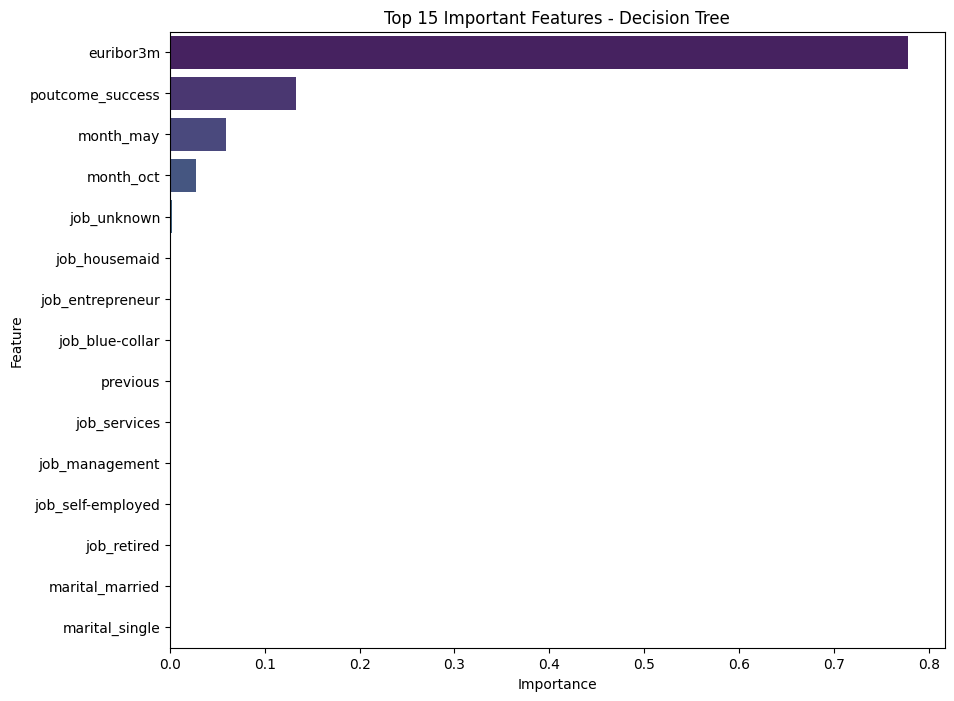

In [257]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 15 Important Features - Decision Tree')

plt.show()

In [258]:
#The Decision Tree analysis revealed that macroeconomic variables such as  Euribor interest rates had the strongest influence on subscription probability.
#Communication strategy variables, as previous customer significantly affected customer responses. Positive coefficients indicated variables associated with higher subscription likelihood, while negative coefficients highlighted factors reducing campaign effectiveness.
#The results suggest that economic conditions and campaign management are more influential than demographic characteristics in predicting term deposit subscriptions.

##### Questions